In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
%matplotlib inline

df = pd.read_csv(r'C:\Users\lavan\Downloads\zomato.csv.zip')

In [5]:
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [6]:
df.shape

(51717, 17)

In [7]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [9]:
df.describe()

,votes
count,51717.000000
mean,283.697527
std,803.838853
min,0.000000
25%,7.000000
50%,41.000000
75%,198.000000
max,16832.000000


In [10]:
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [39]:
# Duplicate Rows

df.duplicated().sum()

0

In [14]:
df.drop_duplicates(inplace=True)

In [40]:
# Rename Columns

df.columns
df.rename(columns={
    "approx_cost(for two people)":"cost_for_two"
}, inplace=True)


In [21]:
# Convert Rating

df["rate"] = df["rate"].str.replace("/5","", regex=False)
df["rate"] = pd.to_numeric(df["rate"], errors="coerce")


In [22]:
# Convert Cost

df["cost_for_two"] = (
    df["cost_for_two"]
    .astype(str)
    .str.replace(",", "")
)

df["cost_for_two"] = pd.to_numeric(df["cost_for_two"], errors="coerce")

In [23]:
# Exploratory Data Analysis (EDA)

df["name"].nunique()

8792

In [24]:
top_locations = df["location"].value_counts().head(10)

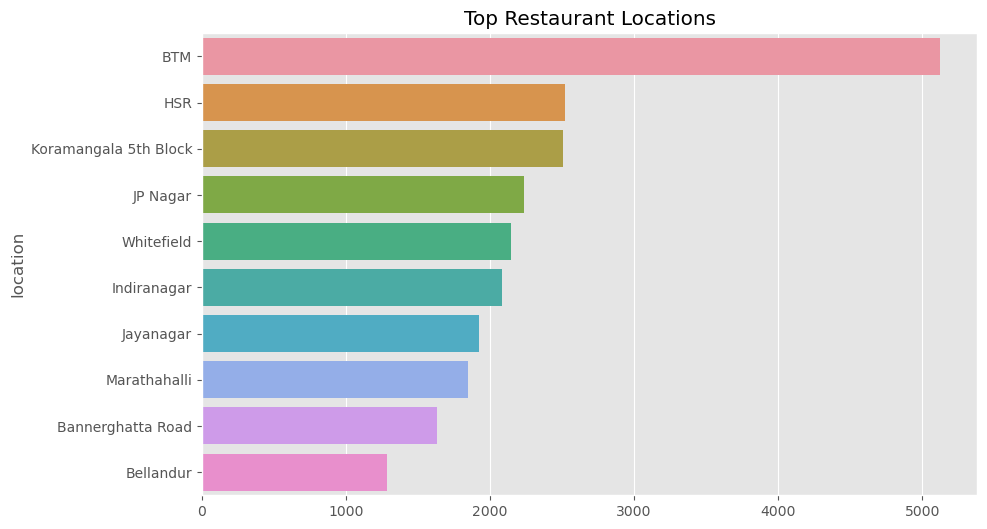

In [25]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_locations.values,
            y=top_locations.index)

plt.title("Top Restaurant Locations")
plt.show()

In [26]:
# Restaurant Types

df["rest_type"].value_counts().head(10)

rest_type
Quick Bites           19132
Casual Dining         10330
Cafe                   3732
Delivery               2604
Dessert Parlor         2263
Takeaway, Delivery     2037
Casual Dining, Bar     1154
Bakery                 1141
Beverage Shop           867
Bar                     697
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='rest_type'>

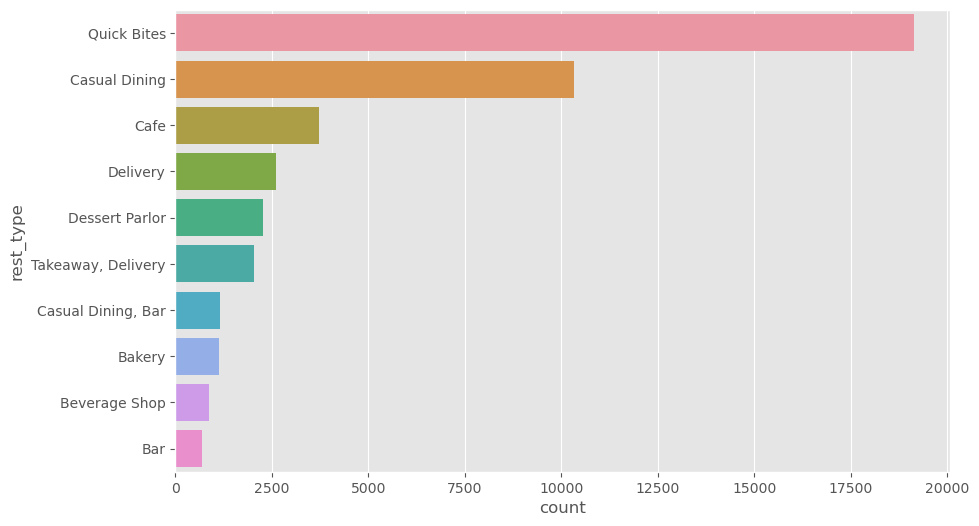

In [27]:
# Graph

plt.figure(figsize=(10,6))
sns.countplot(
    y="rest_type",
    data=df,
    order=df["rest_type"].value_counts().head(10).index
)

<Axes: xlabel='online_order', ylabel='count'>

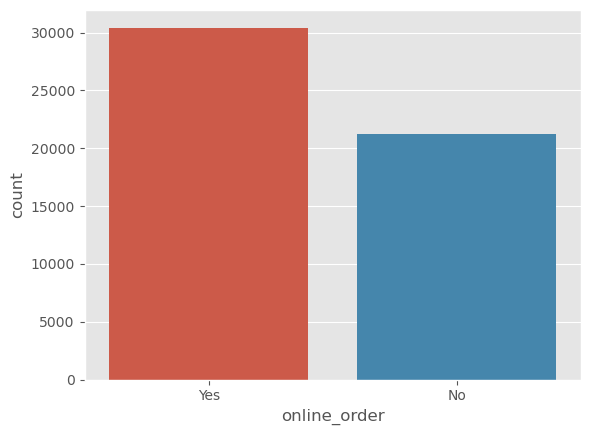

In [28]:
# Online Orders

sns.countplot(
    x="online_order",
    data=df
)

<Axes: xlabel='book_table', ylabel='count'>

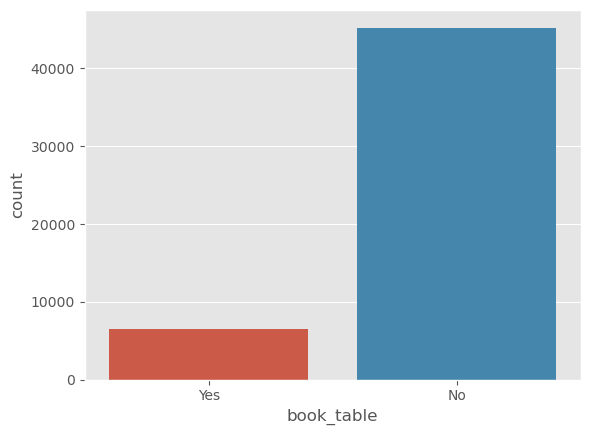

In [29]:
# Table Booking

sns.countplot(
    x="book_table",
    data=df
)

<Axes: xlabel='rate', ylabel='Count'>

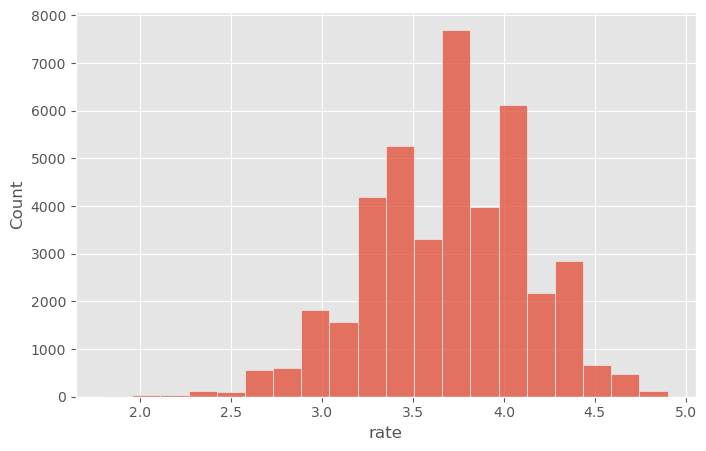

In [30]:
# Rating Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["rate"], bins=20)

<Axes: xlabel='cost_for_two', ylabel='Count'>

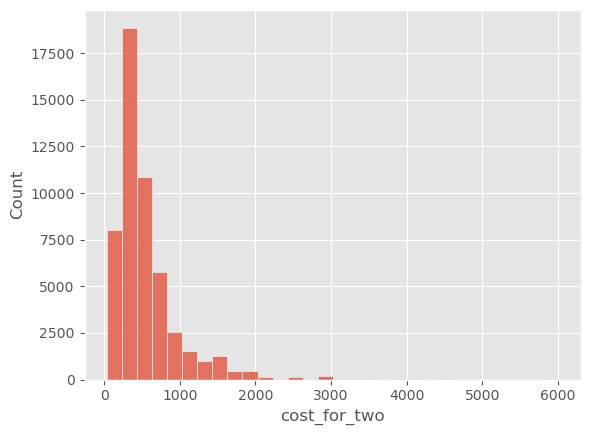

In [31]:
# Cost Distribution

sns.histplot(
    df["cost_for_two"],
    bins=30
)

<Axes: xlabel='votes', ylabel='Count'>

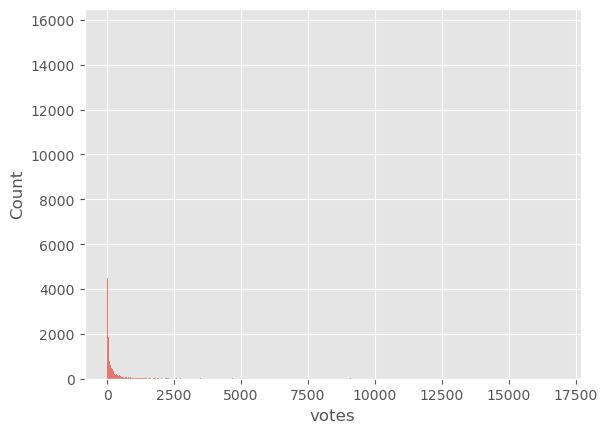

In [32]:
# Votes Distribution

sns.histplot(
    df["votes"]
)

In [33]:
# Highest Rated Restaurants

df.sort_values(
    "rate",
    ascending=False
)[["name","rate"]].head(10)

,name,rate
35082,Asia Kitchen By Mainland China,4.9
37613,Asia Kitchen By Mainland China,4.9
10879,Asia Kitchen By Mainland China,4.9
17877,Belgian Waffle Factory,4.9
4944,Byg Brewski Brewing Company,4.9
47987,Belgian Waffle Factory,4.9
51042,Flechazo,4.9
39559,Punjab Grill,4.9
43055,Belgian Waffle Factory,4.9
37099,AB's - Absolute Barbecues,4.9


In [34]:
# Most Expensive Restaurants

df.sort_values(
    "cost_for_two",
    ascending=False
).head(10)

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,cost_for_two,reviews_list,menu_item,listed_in(type),listed_in(city)
45618,https://www.zomato.com/bangalore/le-cirque-sig...,"The Leela Palace, 23, Old Airport Road, Bangalore",Le Cirque Signature - The Leela Palace,No,Yes,4.3,128,080 30571234\n080 30571540,Old Airport Road,Fine Dining,"Wine, Asparagus Soup, Creme Brulee, Pasta, Rav...","French, Italian",6000.0,"[('Rated 5.0', 'RATED\n Awesome would be an u...",[],Dine-out,Old Airport Road
19139,https://www.zomato.com/bangalore/le-cirque-sig...,"The Leela Palace, 23, Old Airport Road, Bangalore",Le Cirque Signature - The Leela Palace,No,Yes,4.3,126,080 30571234\r\n080 30571540,Old Airport Road,Fine Dining,"Wine, Asparagus Soup, Creme Brulee, Pasta, Rav...","French, Italian",6000.0,"[('Rated 5.0', 'RATED\n Awesome would be an u...",[],Dine-out,Indiranagar
40266,https://www.zomato.com/bangalore/royal-afghan-...,"ITC Windsor, 25 Windsor Square, Sankey Road, B...",Royal Afghan - ITC Windsor,No,Yes,4.3,413,080 61401227,Sankey Road,Fine Dining,"Dal Bukhara, Chocolate Cake, Butter Chicken, N...","North Indian, Mughlai",5000.0,"[('Rated 5.0', 'RATED\n It is just Bukhara wi...",[],Dine-out,Malleshwaram
41591,https://www.zomato.com/bangalore/malties-radis...,"Radisson Blu, 90/4, Outer Ring Road, Munnekoll...",Malties - Radisson Blu,No,No,4.3,53,080 49652584,Marathahalli,Lounge,"Cocktails, Jumbo Prawns, Charcuterie Platter, ...","Continental, Fast Food",4500.0,"[('Rated 3.0', ""RATED\n We had visited this p...",[],Dine-out,Marathahalli
42141,https://www.zomato.com/bangalore/malties-radis...,"Radisson Blu, 90/4, Outer Ring Road, Munnekoll...",Malties - Radisson Blu,No,No,4.3,53,080 49652584,Marathahalli,Lounge,"Cocktails, Jumbo Prawns, Charcuterie Platter, ...","Continental, Fast Food",4500.0,"[('Rated 3.0', ""RATED\n We had visited this p...",[],Drinks & nightlife,Marathahalli
40262,https://www.zomato.com/bangalore/la-brasserie-...,"Le Meridien, 28, Sankey Road, Bangalore",La Brasserie - Le Meridien,No,Yes,4.1,309,080 22262233\n080 22282828,Sankey Road,Fine Dining,"Pasta, Veg Sushi, Biryani, Lunch Buffet, Waffl...","North Indian, Continental, Japanese, Chinese, ...",4100.0,"[('Rated 5.0', 'RATED\n We were here for thei...",[],Dine-out,Malleshwaram
39416,https://www.zomato.com/bangalore/la-brasserie-...,"Le Meridien, 28, Sankey Road, Bangalore",La Brasserie - Le Meridien,No,Yes,4.1,309,080 22262233\n080 22282828,Sankey Road,Fine Dining,"Pasta, Veg Sushi, Biryani, Lunch Buffet, Waffl...","North Indian, Continental, Japanese, Chinese, ...",4100.0,"[('Rated 5.0', 'RATED\n We were here for thei...",[],Buffet,Malleshwaram
39125,https://www.zomato.com/bangalore/la-brasserie-...,"Le Meridien, 28, Sankey Road, Bangalore",La Brasserie - Le Meridien,No,Yes,4.1,309,080 22262233\n080 22282828,Sankey Road,Fine Dining,"Pasta, Veg Sushi, Biryani, Lunch Buffet, Waffl...","North Indian, Continental, Japanese, Chinese, ...",4100.0,"[('Rated 5.0', 'RATED\n We were here for thei...",[],Dine-out,Lavelle Road
37715,https://www.zomato.com/bangalore/la-brasserie-...,"Le Meridien, 28, Sankey Road, Bangalore",La Brasserie - Le Meridien,No,Yes,4.1,309,080 22262233\n080 22282828,Sankey Road,Fine Dining,"Pasta, Veg Sushi, Biryani, Lunch Buffet, Waffl...","North Indian, Continental, Japanese, Chinese, ...",4100.0,"[('Rated 5.0', 'RATED\n We were here for thei...",[],Buffet,Lavelle Road
13071,https://www.zomato.com/bangalore/masala-klub-t...,"Taj West End, Race Course Road, Bangalore",Masala Klub - The Taj West End,No,Yes,4.4,309,080 66605660,Race Course Road,Fine Dining,"Chocolate Cake, Wine, Meat Curry, Dal Makhani,...","North Indian, South Indian",4000.0,"[('Rated 5.0', 'RATED\n Food 5/5\nService 5/5...",[],Dine-out,Church Street


In [35]:
# Best Location by Rating

df.groupby("location")["rate"].mean().sort_values(ascending=False).head(10)

location
Lavelle Road             4.142505
Koramangala 3rd Block    4.020419
St. Marks Road           4.017201
Koramangala 5th Block    4.005821
Church Street            3.992125
Sankey Road              3.965385
Koramangala 4th Block    3.918668
Cunningham Road          3.901053
Residency Road           3.863636
MG Road                  3.855857
Name: rate, dtype: float64

<Axes: xlabel='online_order', ylabel='rate'>

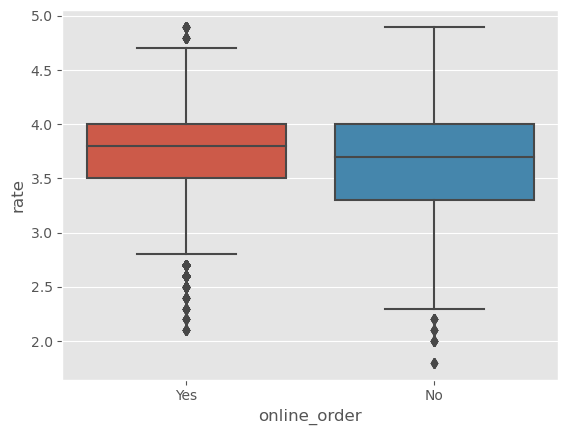

In [36]:
# Online Order vs Rating

sns.boxplot(
    x="online_order",
    y="rate",
    data=df
)

<Axes: xlabel='cost_for_two', ylabel='rate'>

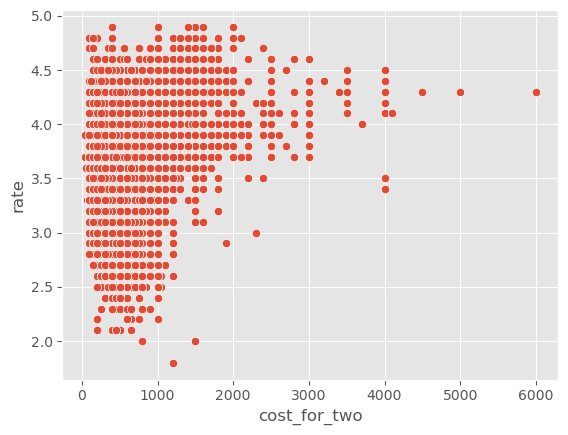

In [37]:
# Cost vs Rating

sns.scatterplot(
    x="cost_for_two",
    y="rate",
    data=df
)

<Axes: >

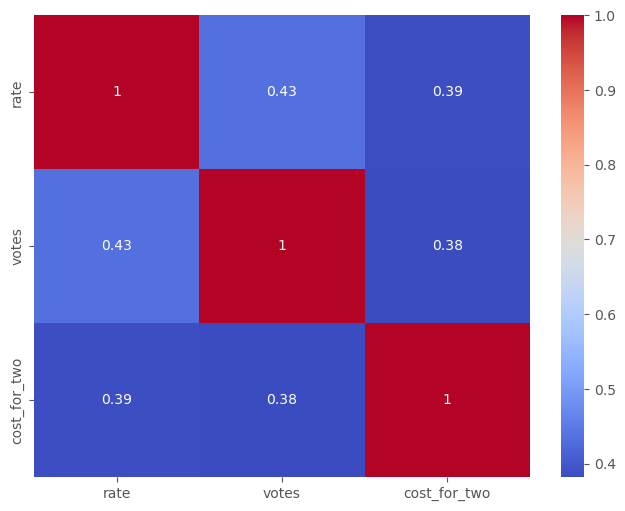

In [38]:
# Correlation Heatmap

corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

In [ ]:
# This project analyzed Zomato restaurant data to discover patterns in ratings, pricing, and customer preferences. 
# The insights obtained can help restaurants make informed business decisions and enhance customer satisfaction.